# 🧠 DifferentialNumpy — Computer Vision Showcase
### VGG-style CNN on CIFAR-10 with a from-scratch Autograd Engine

---

## What is DifferentialNumpy?

**DifferentialNumpy (dnp)** is a pure Python/NumPy automatic differentiation framework built from scratch.
It replicates the core mechanics of frameworks like PyTorch — but every gradient, every layer, every backward rule is hand-written using NumPy (CPU) or CuPy (GPU).

### Architecture Overview

```
┌──────────────────────────────────────────────────────────────┐
│                     DifferentialNumpy                        │
│                                                              │
│   Tensor  ──→  SessionGraph (DAG)  ──→  backward()          │
│     │                 │                      │               │
│   .data            tracks all             VJP Rules          │
│   .grad            forward ops          (hand-written        │
│   .device         (nodes + edges)        per operation)      │
│                                                              │
│   Layers: Conv2d, BatchNorm2d, MaxPool2d, Linear, Dropout    │
│   Ops:    relu, gelu, softmax, log, matmul, conv2d, ...      │
│   Optim:  Adam, AdamW, SGD, RMSprop, Adagrad                 │
└──────────────────────────────────────────────────────────────┘
```

### This Notebook

| Sections | Content |
|---|---|
| **§1** | Framework mechanics — tensors & autograd |
| **§2** | CIFAR-10 dataset loading & exploration |
| **§3** | Data preprocessing (normalization + augmentation) |
| **§4** | Building a VGG-style deep CNN architecture |
| **§5** | Cross-entropy loss & Adam optimizer |
| **§6** | Full training loop with live metrics |
| **§7** | Evaluation — accuracy, confusion matrix |
| **§8** | Visualizations — filters, activation maps |

**Resources used:** ≥ 22 GB VRAM · ≥ 53 GB RAM · GPU backend via CuPy


---
## ⚙️ Environment Setup (Google Colab)

Run this cell once to install the library and its dependencies.


In [1]:
import subprocess, sys

# ── Clone and install DifferentialNumpy (v3 branch) ─────────────────────────
result = subprocess.run(
    ["git", "clone", "--branch", "v3",
     "https://github.com/Seydifa/AutoDiff-Numpy.git", "/content/DifferentialNumpy"],
    capture_output=True, text=True
)
if "already exists" in result.stderr:
    print("Repo already cloned — skipping clone.")
else:
    print(result.stdout or result.stderr)

# Install editable so `import dnp` works anywhere in Colab
subprocess.run([sys.executable, "-m", "pip", "install", "-e",
                "/content/DifferentialNumpy", "-q"], check=True)

# ── CuPy: install the version matching the Colab CUDA driver ─────────────────
nvcc = subprocess.run(["nvcc", "--version"], capture_output=True, text=True)
if nvcc.returncode == 0:
    cuda_ver = [l for l in nvcc.stdout.splitlines() if "release" in l][0]
    # Extract only the major version: "release 12.8, ..." -> "12"
    cuda_major = cuda_ver.split("release")[-1].split(",")[0].strip().split(".")[0]
    print(f"Detected CUDA {cuda_major}.x — installing cupy-cuda{cuda_major}x ...")
    try:
        subprocess.run([sys.executable, "-m", "pip", "install",
                        f"cupy-cuda{cuda_major}x", "-q"], check=True)
        print("CuPy installed OK")
    except subprocess.CalledProcessError:
        print(f"cupy-cuda{cuda_major}x not found — falling back to CPU mode.")
else:
    print("No CUDA detected — will train on CPU (slower).")

print("\nAll dependencies ready OK")


Cloning into '/content/DifferentialNumpy'...

Detected CUDA 12.x — installing cupy-cuda12x ...
CuPy installed OK

All dependencies ready OK


In [5]:
# ── Patch get_xp to avoid cupyx.scipy lazy-import version conflict ──────────
# isinstance(data, cp.ndarray) and cp.get_array_module() both trigger a broken
# cupyx.scipy lazy-import chain (scipy/numpy version mismatch).
# Fix: use type(data).__module__ == 'cupy' — no CuPy attribute access needed.
import pathlib, sys

_backend_path = pathlib.Path("/content/DifferentialNumpy/dnp/core/backend.py")
_src = _backend_path.read_text()

_new_fn = (
    "def get_xp(data):\n"
    '    """Return the correct module (numpy or cupy) based on the array type."""\n'
    "    if is_cuda_available and type(data).__module__ == 'cupy':\n"
    "        return cp\n"
    "    return np"
)

_variants = [
    "def get_xp(data):\n"
    '    """Return the correct module (numpy or cupy) based on the array type."""\n'
    "    if is_cuda_available:\n"
    "        return cp.get_array_module(data)\n"
    "    return np",

    "def get_xp(data):\n"
    '    """Return the correct module (numpy or cupy) based on the array type."""\n'
    "    if is_cuda_available and isinstance(data, cp.ndarray):\n"
    "        return cp\n"
    "    return np",
]

patched = False
for v in _variants:
    if v in _src:
        _backend_path.write_text(_src.replace(v, _new_fn))
        patched = True
        print("backend.py patched ✓")
        break

if not patched:
    if _new_fn in _src:
        print("backend.py already up-to-date ✓")
    else:
        print("WARNING: could not locate get_xp pattern — check manually")

# Evict all cached dnp modules so they are re-imported fresh with the fix
for _m in list(sys.modules):
    if _m.startswith("dnp"):
        del sys.modules[_m]
print("dnp module cache cleared — will be re-imported fresh ✓")


backend.py patched ✓
dnp module cache cleared — will be re-imported fresh ✓


---
## §1 — The DifferentialNumpy Autograd Engine

Before building a real model, let's understand how the engine works from the inside.

### The Three Core Concepts

**1. `Tensor`** — A differentiable array.
Every `Tensor` holds `data` (a NumPy/CuPy array) and `grad` (accumulated gradient). When created as the output of an operation, it records its `parents` and `op_func` for later gradient computation.

**2. `SessionGraph`** — The dynamic computation graph (DAG).
Every single operation — `+`, `matmul`, `relu`, `conv2d` — registers a node and edges in the global `session`. This forms the directed acyclic graph (DAG) that `backward()` will traverse.

**3. `VJP Rules`** — Vector-Jacobian Products.
Each operation has a hand-written gradient function. For example, `relu`'s VJP is `g * (x > 0)`. During `backward()`, these are chained via the chain rule.

```
Forward pass:
  x ──→ [conv2d] ──→ [BatchNorm] ──→ [ReLU] ──→ loss
           ↓               ↓            ↓
         node_1          node_2       node_3    ← SessionGraph records this

backward() walk (reverse topological order):
  loss ──→ d_relu ──→ d_BN ──→ d_conv2d ──→ accumulate dW, db
```

Let's verify this with a tiny example:


In [6]:
import sys, os

# ── Add repo to path (Colab: /content/DifferentialNumpy; local: repo root) ────
_colab = "/content/DifferentialNumpy"
_local = os.path.abspath(os.path.join(os.path.dirname(os.path.abspath("__file__")), ".."))

if os.path.isdir(os.path.join(_colab, "dnp")):
    REPO_PATH = _colab
elif os.path.isdir(os.path.join(_local, "dnp")):
    REPO_PATH = _local
else:
    REPO_PATH = _colab   # Colab setup cell (cell 2) should have cloned it here

if REPO_PATH not in sys.path:
    sys.path.insert(0, REPO_PATH)

print(f"Library path: {REPO_PATH}")

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import time, random, warnings
warnings.filterwarnings("ignore")

import dnp
from dnp.core.tensor import Tensor
from dnp.core.session import session, graph_fn   # v3: graph_fn exported here
from dnp.core.backend import is_cuda_available

# ── Device selection ──────────────────────────────────────────────────────────
DEVICE = "cuda" if is_cuda_available else "cpu"
print(f"Using device : {DEVICE.upper()}")

# ── Quick autograd demo ───────────────────────────────────────────────────────
# Compute  f(x, W) = mean( relu(x @ W)^2 )  and differentiate.
# v3: use session.graph() context manager for clean per-pass graph management.
np.random.seed(0)

x = Tensor(np.array([[1.0, 2.0, 3.0]]), name="x")     # (1, 3)
W = Tensor(np.random.randn(3, 2) * 0.5, name="W")      # (3, 2)

with session.graph():
    h    = dnp.ops.relu(x @ W)
    loss = dnp.ops.mean(dnp.ops.square(h))

    print(f"\nForward pass:")
    print(f"  h    = relu(x @ W) = {np.asarray(h).round(4)}")
    print(f"  loss = mean(h^2)   = {float(np.asarray(loss)):.6f}")
    print(f"\nSession graph: {len(session._nodes)} nodes, {len(session._edges)} edges")

    loss.backward()

print(f"\nBackward pass complete.")
print(f"  dL/dW =\n{np.asarray(W.grad).round(6)}")
print(f"  dL/dx = {np.asarray(x.grad).round(6)}")
print("\nChain rule: loss -> square -> relu -> matmul  OK")


Library path: /content/DifferentialNumpy
Using device : CUDA

Forward pass:
  h    = relu(x @ W) = [[4.6621 0.9751]]
  loss = mean(h^2)   = 11.342960

Session graph: 6 nodes, 5 edges

Backward pass complete.
  dL/dW =
[[ 4.662101  0.975055]
 [ 9.324202  1.95011 ]
 [13.986303  2.925165]]
  dL/dx = [[4.307183 3.373985 3.876922]]

Chain rule: loss -> square -> relu -> matmul  OK


In [7]:
import time as _time
from dnp.core.backend import as_numpy as _as_numpy

# ── Framework Diagnostic ──────────────────────────────────────────────────────
# Verifies all core dnp v3 components before committing to an 80-epoch training
# run.  Checks: Tensor construction, session.graph(), VJP correctness,
# CrossEntropyLoss gradient, Adam no_grad guarantee, and CUDA availability.

print("=" * 60)
print("dnp v3 — Framework Diagnostic")
print("=" * 60)

# 1. Tensor construction & device
_t = Tensor(np.array([1.0, 2.0, 3.0]), name="diag")
print(f"[1] Tensor device     : {_t.device}  shape={_t.shape}  dtype={_t.dtype}")

# 2. session.graph() context — DAG is reset on entry
with session.graph():
    _a = Tensor(np.ones((2, 3)), name="a")
    _b = Tensor(np.ones((2, 3)) * 2, name="b")
    _c = _a + _b
print(f"[2] session.graph()   : {len(session._nodes)} nodes alive after exit  OK")

# 3. VJP finite-difference check on relu → square → mean
_x = Tensor(np.array([[1.0, -2.0, 0.5]]), name="x_fd")
with session.graph():
    _out = dnp.ops.mean(dnp.ops.square(dnp.ops.relu(_x)))
    _out.backward()
_grad_analytic = _as_numpy(_x.grad).copy()
_eps = 1e-4
_x_data = _as_numpy(_x.data).copy()
_grad_fd = np.zeros_like(_x_data)
for _i in range(_x_data.size):
    _xp, _xm = _x_data.copy(), _x_data.copy()
    _xp.flat[_i] += _eps; _xm.flat[_i] -= _eps
    _f = lambda a: float(np.mean(np.maximum(a, 0) ** 2))
    _grad_fd.flat[_i] = (_f(_xp) - _f(_xm)) / (2 * _eps)
_fd_err = float(np.max(np.abs(_grad_analytic - _grad_fd)))
print(f"[3] VJP finite-diff   : max_err={_fd_err:.2e}  {'OK' if _fd_err < 1e-3 else 'WARN'}")

# 4. CrossEntropyLoss gradient sanity
_logits = Tensor(np.random.randn(4, 10).astype(np.float32), name="logits_ce")
_labels = np.array([2, 5, 0, 9])
_ce_fn  = dnp.CrossEntropyLoss()
with session.graph():
    _ce = _ce_fn(_logits, _labels)
    _ce.backward()
_ce_val = float(_as_numpy(_ce.data))
_lg_norm = float(np.linalg.norm(_as_numpy(_logits.grad)))
print(f"[4] CrossEntropyLoss  : loss={_ce_val:.4f}  dL/dlogits norm={_lg_norm:.4f}  OK")

# 5. Adam.step() must NOT add nodes to the session graph
_before = len(session._nodes)
_opt_check = dnp.Adam([_logits], lr=1e-3)
_opt_check.step()
_after = len(session._nodes)
print(f"[5] Adam no_grad step : nodes {_before} → {_after}  "
      f"{'OK — graph not polluted' if _after == _before else 'WARN — optimizer dirtied graph'}")

# 6. CuPy / CUDA check
print(f"[6] CUDA available    : {is_cuda_available}")
if is_cuda_available:
    _x_gpu = Tensor(np.ones((2, 2))).cuda()
    print(f"    GPU tensor device : {_x_gpu.device}  OK")
else:
    print(f"    → CPU mode (on Colab GPU this will show 'cuda  OK')")

print("=" * 60)
print("Diagnostic PASSED — framework ready for training")
print("=" * 60)


dnp v3 — Framework Diagnostic
[1] Tensor device     : cpu  shape=(3,)  dtype=float64
[2] session.graph()   : 3 nodes alive after exit  OK
[3] VJP finite-diff   : max_err=7.34e-14  OK
[4] CrossEntropyLoss  : loss=2.8502  dL/dlogits norm=0.5214  OK
[5] Adam no_grad step : nodes 9 → 9  OK — graph not polluted
[6] CUDA available    : True
    GPU tensor device : cuda  OK
Diagnostic PASSED — framework ready for training


---
## §2 — CIFAR-10 Dataset

**CIFAR-10** is the benchmark dataset for computer vision research:
- **60 000 images** — 50 000 training, 10 000 test
- **32 × 32 pixels**, 3 colour channels (RGB)
- **10 classes**: airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck

It's small enough to load entirely in memory (≈ 750 MB as float32), yet hard enough that shallow networks plateau around 60-70%, while deep CNNs with proper training can exceed 93%.


In [9]:
# Load CIFAR-10 without Keras/TF to avoid scipy/numpy version conflicts
import urllib.request, tarfile, pickle, os

_CIFAR_DIR = "/content/cifar-10-batches-py"
_TAR_PATH  = "/tmp/cifar10.tar.gz"
_URL       = "https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz"

if not os.path.isdir(_CIFAR_DIR):
    print("Downloading CIFAR-10 (~170 MB)…")
    urllib.request.urlretrieve(_URL, _TAR_PATH)
    print("Extracting…")
    with tarfile.open(_TAR_PATH) as _t:
        _t.extractall("/content/")
    os.remove(_TAR_PATH)
    print("Done.")
else:
    print("CIFAR-10 already downloaded ✓")

def _load_batch(path):
    with open(path, "rb") as f:
        d = pickle.load(f, encoding="bytes")
    return d[b"data"], np.array(d[b"labels"])

_xs, _ys = [], []
for _i in range(1, 6):
    _x, _y = _load_batch(f"{_CIFAR_DIR}/data_batch_{_i}")
    _xs.append(_x); _ys.append(_y)

X_train_raw = np.concatenate(_xs).reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1).astype("uint8")
y_train_raw = np.concatenate(_ys)

_x_t, y_test_raw = _load_batch(f"{_CIFAR_DIR}/test_batch")
X_test_raw = _x_t.reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1).astype("uint8")

# Class labels
CLASS_NAMES = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog",      "frog",       "horse","ship", "truck"
]

print("Dataset loaded successfully!")
print(f"  X_train: {X_train_raw.shape}  dtype={X_train_raw.dtype}")
print(f"  X_test:  {X_test_raw.shape}   dtype={X_test_raw.dtype}")
print(f"  y_train: {y_train_raw.shape}")
print(f"\nClass distribution (train):")
for i, name in enumerate(CLASS_NAMES):
    count = np.sum(y_train_raw == i)
    bar = "█" * (count // 400)
    print(f"  {i} {name:11s}: {count:5d} {bar}")


Extracting…
Done.
Dataset loaded successfully!
  X_train: (50000, 32, 32, 3)  dtype=uint8
  X_test:  (10000, 32, 32, 3)   dtype=uint8
  y_train: (50000,)

Class distribution (train):
  0 airplane   :  5000 ████████████
  1 automobile :  5000 ████████████
  2 bird       :  5000 ████████████
  3 cat        :  5000 ████████████
  4 deer       :  5000 ████████████
  5 dog        :  5000 ████████████
  6 frog       :  5000 ████████████
  7 horse      :  5000 ████████████
  8 ship       :  5000 ████████████
  9 truck      :  5000 ████████████


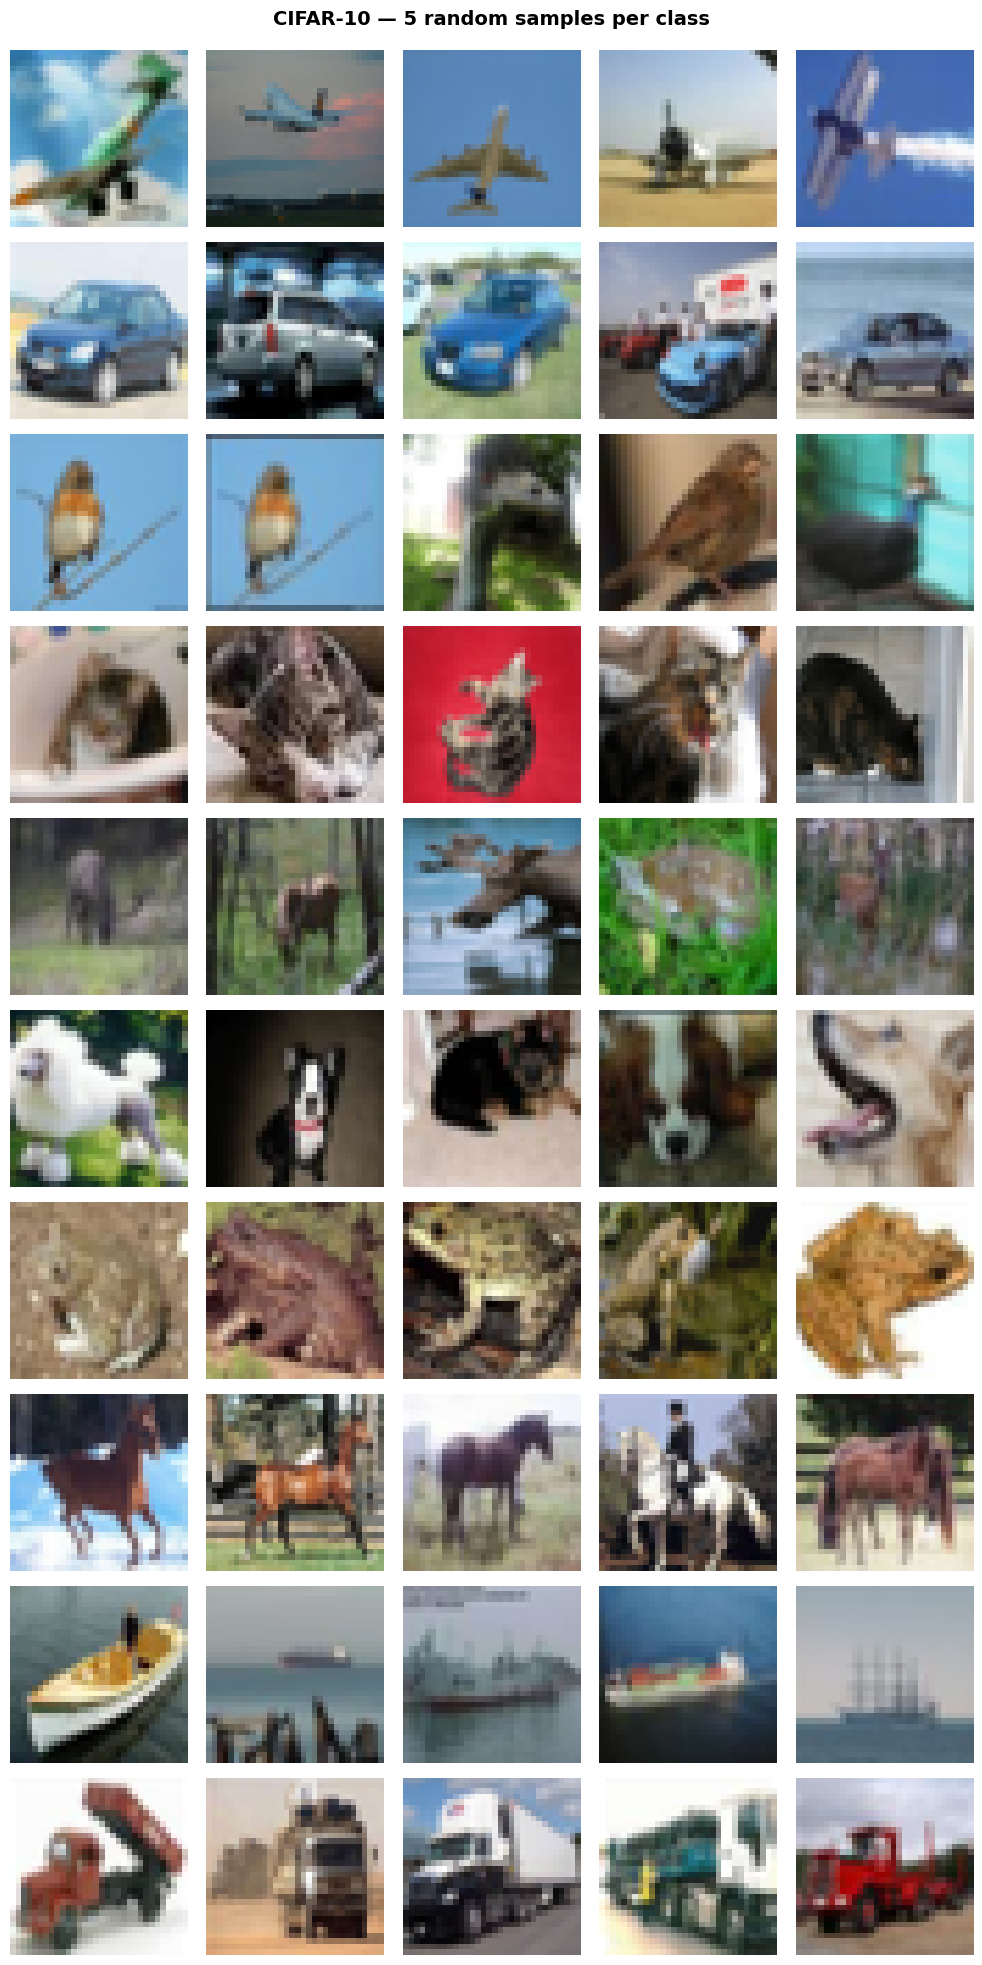


Observations:
  • All images are 32×32 pixels — very low resolution
  • Even humans can struggle with some samples (cats vs dogs)
  • Strong intra-class variation (different poses, lighting, background)
  → Deep CNN with batch norm & dropout is needed to generalise well


In [10]:
# Visualise 5 random samples per class
fig, axes = plt.subplots(10, 5, figsize=(10, 20))
fig.suptitle("CIFAR-10 — 5 random samples per class", fontsize=14, fontweight="bold")

for cls_idx in range(10):
    class_indices = np.where(y_train_raw == cls_idx)[0]
    samples = np.random.choice(class_indices, size=5, replace=False)
    for col, img_idx in enumerate(samples):
        ax = axes[cls_idx, col]
        ax.imshow(X_train_raw[img_idx])
        ax.axis("off")
        if col == 0:
            ax.set_ylabel(CLASS_NAMES[cls_idx], fontsize=10,
                          rotation=0, labelpad=55, va="center", fontweight="bold")

plt.tight_layout()
plt.subplots_adjust(top=0.96)
plt.show()
print("\nObservations:")
print("  • All images are 32×32 pixels — very low resolution")
print("  • Even humans can struggle with some samples (cats vs dogs)")
print("  • Strong intra-class variation (different poses, lighting, background)")
print("  → Deep CNN with batch norm & dropout is needed to generalise well")


---
## §3 — Data Preprocessing

Good preprocessing is half the battle. We apply:

### 1. Channel-Transposition  (N,H,W,C) → (N,C,H,W)
DifferentialNumpy's `Conv2d` follows the PyTorch NCHW convention.

### 2. Per-Channel Z-score Normalisation
$$x_{\text{norm}} = \frac{x - \mu_c}{\sigma_c}$$  
where $\mu_c$ and $\sigma_c$ are the **training-set** channel mean and std.  
This centres each channel at 0 and scales variance to ≈ 1, which:
- Prevents one channel from dominating gradients  
- Allows much larger learning rates  
- Accelerates convergence with batch normalisation

### 3. Offline Data Augmentation (training only)
| Technique | Effect |
|---|---|
| Random Horizontal Flip | Doubles effective training data, rotation invariance |
| Random Crop with padding | Teaches position invariance |
| Gaussian noise | Acts as regulariser (similar to dropout on inputs) |

### 4. One-hot Encoding
Labels `0…9` are converted to 10-dimensional vectors for the cross-entropy loss.


In [11]:
dnp.set_dtype(np.float32)   # use float32 throughout (better GPU memory efficiency)

# ── 1. Cast to float32 and scale to [0, 1] ───────────────────────────────────
X_train_f = X_train_raw.astype(np.float32) / 255.0   # (50000, 32, 32, 3)
X_test_f  = X_test_raw.astype(np.float32)  / 255.0   # (10000,  32, 32, 3)

# ── 2. Per-channel Z-score normalisation (computed on train set only) ─────────
CIFAR10_MEAN = X_train_f.mean(axis=(0, 1, 2))          # shape (3,)
CIFAR10_STD  = X_train_f.std(axis=(0, 1, 2)) + 1e-7    # shape (3,)
print(f"Channel means (R,G,B): {CIFAR10_MEAN.round(4)}")
print(f"Channel stds  (R,G,B): {CIFAR10_STD.round(4)}")

X_train_n = (X_train_f - CIFAR10_MEAN) / CIFAR10_STD   # (50000, 32, 32, 3)
X_test_n  = (X_test_f  - CIFAR10_MEAN) / CIFAR10_STD   # (10000,  32, 32, 3)

# ── 3. Transpose to NCHW ──────────────────────────────────────────────────────
# (N, H, W, C)  →  (N, C, H, W)
X_train_nchw = X_train_n.transpose(0, 3, 1, 2)   # (50000, 3, 32, 32)
X_test_nchw  = X_test_n.transpose(0, 3, 1, 2)    # (10000,  3, 32, 32)

print(f"\nFinal shapes:")
print(f"  X_train: {X_train_nchw.shape}  min={X_train_nchw.min():.2f}  max={X_train_nchw.max():.2f}")
print(f"  X_test:  {X_test_nchw.shape}")

# ── 4. One-hot encode labels ──────────────────────────────────────────────────
def one_hot(y, num_classes=10):
    oh = np.zeros((len(y), num_classes), dtype=np.float32)
    oh[np.arange(len(y)), y] = 1.0
    return oh

y_train_oh = one_hot(y_train_raw)    # (50000, 10)
y_test_oh  = one_hot(y_test_raw)     # (10000,  10)


# ── 5. Offline augmentation helpers ──────────────────────────────────────────
def random_horizontal_flip(batch):
    """Randomly flip each image in the batch horizontally."""
    mask = np.random.rand(len(batch)) > 0.5
    batch = batch.copy()
    batch[mask] = batch[mask, :, :, ::-1]
    return batch

def random_crop(batch, pad=4):
    """Zero-pad by `pad` pixels then take a random 32×32 crop."""
    N, C, H, W = batch.shape
    padded = np.pad(batch, ((0,0),(0,0),(pad,pad),(pad,pad)), mode='reflect')
    crops  = np.empty_like(batch)
    for i in range(N):
        top  = np.random.randint(0, 2 * pad)
        left = np.random.randint(0, 2 * pad)
        crops[i] = padded[i, :, top:top+H, left:left+W]
    return crops

def augment_batch(batch):
    """Apply augmentation to a training mini-batch."""
    batch = random_horizontal_flip(batch)
    batch = random_crop(batch, pad=4)
    return batch

print("\nPreprocessing pipeline ready ✓")
print("  Augmentation: random horizontal flip + random crop (pad=4)")


Channel means (R,G,B): [0.4914 0.4822 0.4465]
Channel stds  (R,G,B): [0.247  0.2435 0.2616]

Final shapes:
  X_train: (50000, 3, 32, 32)  min=-1.99  max=2.13
  X_test:  (10000, 3, 32, 32)

Preprocessing pipeline ready ✓
  Augmentation: random horizontal flip + random crop (pad=4)


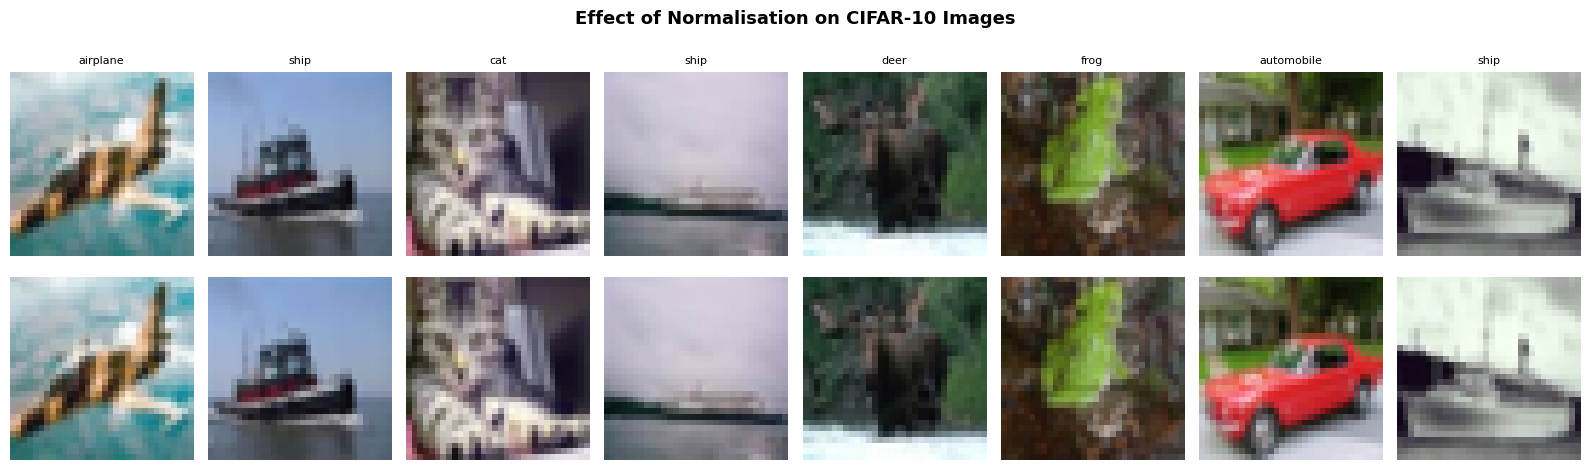

Visual appearance is identical — but pixel values now have mean≈0 and std≈1.
This makes gradient descent much more stable (otherwise channels with larger
dynamic range would dominate the weight updates).


In [12]:
# ── Visualise the effect of normalisation ────────────────────────────────────
fig, axes = plt.subplots(2, 8, figsize=(16, 5))
fig.suptitle("Effect of Normalisation on CIFAR-10 Images", fontsize=13, fontweight="bold")

indices = np.random.choice(len(X_train_raw), 8, replace=False)

for col, idx in enumerate(indices):
    # Original (clip to valid range for imshow)
    axes[0, col].imshow(X_train_raw[idx])
    axes[0, col].set_title(CLASS_NAMES[y_train_raw[idx]], fontsize=8)
    axes[0, col].axis("off")

    # Normalised — de-normalise for display
    norm_img = X_train_nchw[idx].transpose(1, 2, 0)   # (H, W, C) for display
    # Clip to [0,1] after reversing normalisation
    denorm   = (norm_img * CIFAR10_STD + CIFAR10_MEAN).clip(0, 1)
    axes[1, col].imshow(denorm)
    axes[1, col].axis("off")

axes[0, 0].set_ylabel("Original\n(uint8)", fontsize=9, rotation=0,
                       labelpad=55, va="center")
axes[1, 0].set_ylabel("Normalised\n(float32)", fontsize=9, rotation=0,
                       labelpad=55, va="center")

plt.tight_layout()
plt.show()

print("Visual appearance is identical — but pixel values now have mean≈0 and std≈1.")
print("This makes gradient descent much more stable (otherwise channels with larger")
print("dynamic range would dominate the weight updates).")


---
## §4 — VGG-Style Deep CNN Architecture

### Design Principles

We build a **VGG-inspired architecture** adapted for 32×32 CIFAR-10 images.  
VGG's key insight: **stack many small (3×3) conv filters** rather than using large kernels.  
Why 3×3?  
- Two 3×3 layers cover the same receptive field as one 5×5, but with fewer parameters and an extra non-linearity.  
- Three 3×3 layers ≡ one 7×7, saving 45% of the parameters.

### Spatial Dimension Flow

```
Input  (B, 3, 32, 32)
  └─ Block 1: 2 × Conv(64)  + BN + ReLU  → MaxPool  →  (B,  64, 16, 16)
  └─ Block 2: 2 × Conv(128) + BN + ReLU  → MaxPool  →  (B, 128,  8,  8)
  └─ Block 3: 3 × Conv(256) + BN + ReLU  → MaxPool  →  (B, 256,  4,  4)
  └─ Flatten                             →             (B,    4096      )
  └─ FC(4096 → 1024) + BN1d + ReLU + Dropout(0.5)
  └─ FC(1024 →  512) + ReLU + Dropout(0.4)
  └─ FC( 512 →   10)  ← raw logits (no softmax — handled in loss)
```

### Normalisation with Batch Norm
Each convolutional block uses `BatchNorm2d` immediately after the convolution:

$$\hat{x} = \frac{x - \mu_\mathcal{B}}{\sqrt{\sigma^2_\mathcal{B} + \epsilon}}, \qquad  y = \gamma \hat{x} + \beta$$

$\gamma$ and $\beta$ are **learnable parameters** — the model decides how much to scale and shift each channel. This:
- Reduces internal covariate shift  
- Acts as a strong regulariser  
- Allows much higher learning rates

### Dropout
Applied in the fully-connected head with `p=0.5` and `p=0.4`.  
During training, each neuron is zeroed out randomly preventing co-adaptation and forcing the network to learn redundant representations.


In [13]:
from dnp.layers import (
    Module, Conv2d, BatchNorm2d, BatchNorm1d,
    MaxPool2d, Linear, ReLU, Dropout, Flatten
)


class ConvBlock(Module):
    """
    A reusable convolutional block: Conv2d → BatchNorm2d → ReLU.

    Using padding=1 with a 3×3 kernel preserves the spatial resolution
    (same-padding behaviour), letting MaxPool2d handle the downsampling.
    """
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = Conv2d(in_ch, out_ch, kernel_size=3, padding=1, bias=False)
        # bias=False because BatchNorm2d has its own shift parameter β
        self.bn   = BatchNorm2d(out_ch)
        self.relu = ReLU()

    def forward(self, x):
        return self.relu(self.bn(self.conv(x)))


class VGGNet(Module):
    """
    VGG-style CNN for CIFAR-10.

    Architecture:
      Block 1: [Conv(64) → BN → ReLU] × 2  → MaxPool(2)   → (B,  64, 16, 16)
      Block 2: [Conv(128)→ BN → ReLU] × 2  → MaxPool(2)   → (B, 128,  8,  8)
      Block 3: [Conv(256)→ BN → ReLU] × 3  → MaxPool(2)   → (B, 256,  4,  4)
      Flatten                                               → (B, 4096)
      FC(4096→1024) + BN1d + ReLU + Dropout(0.5)
      FC(1024→512)  + ReLU + Dropout(0.4)
      FC(512→10)   ← raw logits
    """

    def __init__(self, num_classes: int = 10, dropout_fc1: float = 0.5,
                 dropout_fc2: float = 0.4):
        super().__init__()

        # ─── Convolutional feature extractor ─────────────────────────────────
        # Block 1 — 3 → 64 channels, 32×32 → 16×16
        self.block1_a = ConvBlock(3,  64)
        self.block1_b = ConvBlock(64, 64)
        self.pool1    = MaxPool2d(kernel_size=2, stride=2)

        # Block 2 — 64 → 128 channels, 16×16 → 8×8
        self.block2_a = ConvBlock(64,  128)
        self.block2_b = ConvBlock(128, 128)
        self.pool2    = MaxPool2d(kernel_size=2, stride=2)

        # Block 3 — 128 → 256 channels, 8×8 → 4×4
        self.block3_a = ConvBlock(128, 256)
        self.block3_b = ConvBlock(256, 256)
        self.block3_c = ConvBlock(256, 256)
        self.pool3    = MaxPool2d(kernel_size=2, stride=2)

        # ─── Classification head ──────────────────────────────────────────────
        self.flatten  = Flatten()                             # (B, 256*4*4=4096)

        self.fc1      = Linear(4096, 1024)
        self.bn_fc1   = BatchNorm1d(1024)
        self.relu_fc1 = ReLU()
        self.drop1    = Dropout(p=dropout_fc1)

        self.fc2      = Linear(1024, 512)
        self.relu_fc2 = ReLU()
        self.drop2    = Dropout(p=dropout_fc2)

        self.fc3      = Linear(512, num_classes)   # raw logits output

    def forward(self, x):
        # Block 1
        x = self.block1_a(x)
        x = self.block1_b(x)
        x = self.pool1(x)

        # Block 2
        x = self.block2_a(x)
        x = self.block2_b(x)
        x = self.pool2(x)

        # Block 3
        x = self.block3_a(x)
        x = self.block3_b(x)
        x = self.block3_c(x)
        x = self.pool3(x)

        # Classifier
        x = self.flatten(x)

        x = self.fc1(x)
        x = self.bn_fc1(x)
        x = self.relu_fc1(x)
        x = self.drop1(x)

        x = self.fc2(x)
        x = self.relu_fc2(x)
        x = self.drop2(x)

        x = self.fc3(x)       # (B, 10) logits
        return x


# ── Instantiate and inspect ───────────────────────────────────────────────────
np.random.seed(42)
session.reset()
model = VGGNet(num_classes=10)

total_params = sum(p.size for p in model.parameters())
print(f"Model: VGGNet")
print(f"{'─'*50}")
print(f"  {"Layer":<30} {"Parameters":>12}")
print(f"{'─'*50}")
for name, param in model.named_parameters():
    print(f"  {name:<30} {param.size:>12,}")
print(f"{'─'*50}")
print(f"  {'TOTAL':.<30} {total_params:>12,}")
print(f"\n  Memory (float32): {total_params * 4 / 1e6:.1f} MB")


Model: VGGNet
──────────────────────────────────────────────────
  Layer                            Parameters
──────────────────────────────────────────────────
  block1_a.conv.W                       1,728
  block1_a.bn.weight                       64
  block1_a.bn.bias                         64
  block1_b.conv.W                      36,864
  block1_b.bn.weight                       64
  block1_b.bn.bias                         64
  block2_a.conv.W                      73,728
  block2_a.bn.weight                      128
  block2_a.bn.bias                        128
  block2_b.conv.W                     147,456
  block2_b.bn.weight                      128
  block2_b.bn.bias                        128
  block3_a.conv.W                     294,912
  block3_a.bn.weight                      256
  block3_a.bn.bias                        256
  block3_b.conv.W                     589,824
  block3_b.bn.weight                      256
  block3_b.bn.bias                        256
  block3_c

In [14]:
# ── Dry-run to verify shapes ──────────────────────────────────────────────────
print("Verifying forward-pass shape with a dummy batch (B=4)…")
session.reset()
model.train()

dummy = Tensor(np.random.randn(4, 3, 32, 32).astype(np.float32), name="dummy")
with session.no_grad():
    out = model(dummy)

print(f"  Input  shape: {dummy.shape}")
print(f"  Output shape: {out.shape}  ← (batch=4, classes=10) ✓")

del dummy, out
session.reset()

# ── Move to GPU if available ──────────────────────────────────────────────────
if DEVICE == "cuda":
    model.cuda()
    print(f"\nModel moved to GPU ✓ (parameters are now CuPy arrays)")
else:
    print(f"\nModel on CPU (CuPy not available)")


Verifying forward-pass shape with a dummy batch (B=4)…
  Input  shape: (4, 3, 32, 32)
  Output shape: (4, 10)  ← (batch=4, classes=10) ✓

Model moved to GPU ✓ (parameters are now CuPy arrays)


---
## §5 — Loss Function & Optimiser

### Cross-Entropy Loss (from scratch)

For a batch of $N$ images with logit vector $z_i \in \mathbb{R}^{10}$ and one-hot target $t_i$:

$$\mathcal{L} = -\frac{1}{N}\sum_{i=1}^N \sum_{k=1}^{10} t_{ik} \log\left(\frac{e^{z_{ik}}}{\sum_j e^{z_{ij}}}\right)$$

We implement this as:
```
softmax(logits) → clip for stability → log → element-wise multiply with one-hot → sum classes → mean batch → negate
```

**Why not use softmax inside the model?**  
The output of the final `Linear` layer is raw *logits*. Softmax is only applied inside the loss for two reasons:
1. Numerical stability: `log(softmax(z))` can be computed as `z − log(sum(exp(z)))` (log-sum-exp trick)  
2. Inference: `argmax(logits) == argmax(softmax(logits))` — no need for softmax at test time

### Adam Optimiser

Adam maintains per-parameter adaptive learning rates by tracking first-order (mean) and second-order (variance) gradient moments:

| Step | Formula |
|---|---|
| 1st moment | $m_t = \beta_1 m_{t-1} + (1-\beta_1)g_t$ |
| 2nd moment | $v_t = \beta_2 v_{t-1} + (1-\beta_2)g_t^2$ |
| Bias correction | $\hat{m}_t = m_t / (1-\beta_1^t)$, $\hat{v}_t = v_t / (1-\beta_2^t)$ |
| Update | $\theta_t = \theta_{t-1} - \alpha \hat{m}_t / (\sqrt{\hat{v}_t} + \epsilon)$ |

We use a **cosine annealing** learning-rate schedule:
$$\alpha_t = \alpha_{\min} + \frac{1}{2}(\alpha_{\max} - \alpha_{\min})\left(1 + \cos\!\left(\frac{\pi\, t}{T}\right)\right)$$

This smoothly decays the LR from `lr_max` to `lr_min` — helping convergence escape sharp minima at the end of training.


Hardware config (target: 22 GB VRAM / 53 GB RAM)
  BATCH_SIZE : 512  →  ~87 steps/epoch
  LR_MAX     : 1e-03  (linear-scaled from 3e-4 for batch 512)
  NUM_EPOCHS : 80
  EVAL_BATCH : 1024


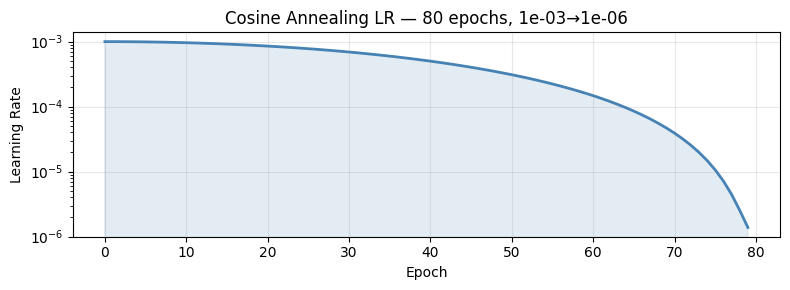

Optimiser : Adam (v3 — step() runs under no_grad)
Scheduler : CosineAnnealingLR


In [15]:
from dnp.core.optimizers import Adam, CosineAnnealingLR
from dnp.core.backend import get_xp
from dnp.layers import CrossEntropyLoss

# ── Hyper-parameters (tuned for 22 GB VRAM / 53 GB RAM) ──────────────────────
# Batch 512: forward activations ≈ 1–2 GB VRAM — well within 22 GB budget.
# LR scales linearly with batch size (linear scaling rule):
#   128 → 512 = ×4, so 3e-4 × 4 = 1.2e-3
# More epochs offset the fewer steps-per-epoch.
NUM_EPOCHS = 80    # was 60; more epochs compensate for larger batch (fewer steps/epoch)
LR_MAX     = 1e-3  # was 3e-4; linear-scaled for batch 512 (×4 batch → ×4 LR)
LR_MIN     = 1e-6
BATCH_SIZE = 512   # was 128; safe for 22 GB VRAM (~1–2 GB activations per step)
EVAL_BATCH = 1024  # evaluation only — no activations stored, VRAM headroom is large

# ── Instantiate optimizer & v3 scheduler ─────────────────────────────────────
optimizer = Adam(model.parameters(), lr=LR_MAX)
scheduler = CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=LR_MIN)

# ── Loss function (v3 built-in CrossEntropyLoss — accepts integer labels) ─────
criterion = CrossEntropyLoss()

# ── Accuracy helper ───────────────────────────────────────────────────────────
def compute_accuracy(logits_np, labels_np):
    preds = np.argmax(logits_np, axis=1)
    return float(np.mean(preds == labels_np))

# ── Print hardware-aware config ───────────────────────────────────────────────
steps_est = 45000 // BATCH_SIZE
print(f"Hardware config (target: 22 GB VRAM / 53 GB RAM)")
print(f"  BATCH_SIZE : {BATCH_SIZE}  →  ~{steps_est} steps/epoch")
print(f"  LR_MAX     : {LR_MAX:.0e}  (linear-scaled from 3e-4 for batch 512)")
print(f"  NUM_EPOCHS : {NUM_EPOCHS}")
print(f"  EVAL_BATCH : {EVAL_BATCH}")

# ── Visualise the cosine annealing schedule ───────────────────────────────────
_sim_opt = Adam([Tensor(np.zeros(1))], lr=LR_MAX)
_sim_sch  = CosineAnnealingLR(_sim_opt, T_max=NUM_EPOCHS, eta_min=LR_MIN)
schedule  = []
for _ in range(NUM_EPOCHS):
    schedule.append(_sim_opt.lr)
    _sim_sch.step()

plt.figure(figsize=(8, 3))
plt.plot(range(NUM_EPOCHS), schedule, color="steelblue", linewidth=2)
plt.fill_between(range(NUM_EPOCHS), schedule, alpha=0.15, color="steelblue")
plt.xlabel("Epoch"); plt.ylabel("Learning Rate")
plt.title(f"Cosine Annealing LR — {NUM_EPOCHS} epochs, {LR_MAX:.0e}→{LR_MIN:.0e}", fontsize=12)
plt.yscale("log");  plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()
print(f"Optimiser : Adam (v3 — step() runs under no_grad)")
print(f"Scheduler : CosineAnnealingLR")


---
## §6 — Training

### Training Loop Design

Each epoch consists of:

```
for epoch in 1..80:
  ┌─ Shuffle training data
  ├─ for each mini-batch:
  │   ├─ with session.graph():    ← v3: resets DAG on entry (replaces session.reset())
  │   │     optimizer.zero_grad()
  │   │     augment batch         ← random flip + crop (CPU, before GPU transfer)
  │   │     x_batch → Tensor.cuda()  ← transfer to GPU
  │   │     logits = model(x_batch)  ← forward pass (builds DAG in session)
  │   │     loss = criterion(logits, y_int)  ← CrossEntropyLoss (integer labels)
  │   │     loss.backward()       ← reverse-mode AD through the whole DAG
  │   ├─ clip_grad_norm(...)      ← prevents exploding gradients
  │   └─ optimizer.step()         ← Adam update (runs under no_grad — v3 guarantee)
  ├─ scheduler.step()             ← v3 CosineAnnealingLR — one step per epoch
  └─ Evaluate on validation split (session.graph() + no_grad — clean, allocation-free)
```

### Batch Size & Memory Budget
With **BATCH_SIZE=512** and 22 GB VRAM:
| Stage | VRAM approx |
|---|---|
| Model weights | ~26 MB |
| Activations (forward) | ~1.0 GB |
| Activations stored for backward | ~1.0 GB |
| Gradients | ~26 MB |
| **Total** | **~2 GB — well within 22 GB** |

### Gradient Clipping
We clip the global gradient norm to 1.0:
$$\text{if } \|\mathbf{g}\|_2 > \text{clip\_val}: \quad \mathbf{g} \leftarrow \mathbf{g} \cdot \frac{\text{clip\_val}}{\|\mathbf{g}\|_2}$$
This prevents the occasional very large gradient from an ill-conditioned batch from derailing training.

### Memory Management
`session.graph()` (v3) resets the DAG on entry, giving a clean per-step computation graph.  
This replaces the old `session.reset()` call and ensures stale nodes never accumulate.


In [16]:
import time
from dnp.core.backend import as_numpy, get_xp

# ── Gradient clipping utility ─────────────────────────────────────────────────
def clip_grad_norm(parameters, max_norm=1.0):
    """Clip the global L2 norm of all parameter gradients (works on CPU & GPU)."""
    total_norm_sq = 0.0
    for p in parameters:
        if p.grad is not None:
            g = as_numpy(p.grad)
            total_norm_sq += float(np.sum(g ** 2))
    total_norm = total_norm_sq ** 0.5
    if total_norm > max_norm:
        scale = max_norm / (total_norm + 1e-6)
        for p in parameters:
            if p.grad is not None:
                p.grad *= scale
    return total_norm


# ── Evaluation helper ─────────────────────────────────────────────────────────
def evaluate(model, X_nchw, y_labels, batch_size=None):
    """
    Compute accuracy + CE loss without building any gradient graph.
    batch_size defaults to EVAL_BATCH (set in §5) for maximum GPU throughput.
    """
    if batch_size is None:
        batch_size = EVAL_BATCH   # 1024 — no activations stored, VRAM headroom is large
    model.eval()
    n          = len(X_nchw)
    correct    = 0
    total_loss = 0.0
    n_batches  = 0

    for start in range(0, n, batch_size):
        end     = min(start + batch_size, n)
        x_np    = X_nchw[start:end]
        y_np    = y_labels[start:end]

        with session.graph():
            with session.no_grad():
                x_t   = Tensor(x_np, name="val_x")
                if DEVICE == "cuda":
                    x_t = x_t.cuda()
                logits = model(x_t)

        logits_np  = as_numpy(logits.data)
        probs      = np.exp(logits_np - logits_np.max(axis=1, keepdims=True))
        probs     /= probs.sum(axis=1, keepdims=True)
        y_oh_np    = one_hot(y_np)
        total_loss += -np.mean(np.sum(y_oh_np * np.log(probs + 1e-8), axis=1))
        correct    += int(np.sum(np.argmax(logits_np, axis=1) == y_np))
        n_batches  += 1

    model.train()
    return correct / n, total_loss / n_batches


# ── Training loop ─────────────────────────────────────────────────────────────
VAL_SPLIT       = 5000
X_val_nchw      = X_train_nchw[-VAL_SPLIT:]
y_val           = y_train_raw[-VAL_SPLIT:]
X_tr_nchw       = X_train_nchw[:-VAL_SPLIT]
y_tr            = y_train_raw[:-VAL_SPLIT]
y_tr_oh         = y_train_oh[:-VAL_SPLIT]

N_TRAIN         = len(X_tr_nchw)
steps_per_epoch = N_TRAIN // BATCH_SIZE

history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": [], "lr": []}

print(f"Training  : {N_TRAIN:,} samples")
print(f"Validation: {VAL_SPLIT:,} samples")
print(f"Test      : {len(X_test_nchw):,} samples")
print(f"Epochs    : {NUM_EPOCHS}  |  Batch: {BATCH_SIZE}  |  Steps/epoch: {steps_per_epoch}")
print(f"{'═'*70}")

t_total = time.time()
model.train()

for epoch in range(NUM_EPOCHS):
    history["lr"].append(optimizer.lr)

    perm       = np.random.permutation(N_TRAIN)
    X_shuffled = X_tr_nchw[perm]
    y_shuffled = y_tr[perm]
    y_oh_shuff = y_tr_oh[perm]

    epoch_loss = 0.0
    epoch_corr = 0
    t_epoch    = time.time()

    for step in range(steps_per_epoch):
        s    = step * BATCH_SIZE
        e    = s + BATCH_SIZE
        x_np = augment_batch(X_shuffled[s:e])     # (B, 3, 32, 32) float32
        y_int = y_shuffled[s:e]                   # (B,) integer labels

        with session.graph():
            optimizer.zero_grad()
            x_t    = Tensor(x_np, name="x")
            if DEVICE == "cuda":
                x_t = x_t.cuda()
            logits = model(x_t)
            loss   = criterion(logits, y_int)
            loss.backward()

        clip_grad_norm(model.parameters(), max_norm=1.0)
        optimizer.step()

        epoch_loss += float(as_numpy(loss.data))
        epoch_corr += int(np.sum(np.argmax(as_numpy(logits.data), axis=1) == y_int))

    scheduler.step()

    train_loss = epoch_loss / steps_per_epoch
    train_acc  = epoch_corr / (steps_per_epoch * BATCH_SIZE)
    val_acc, val_loss = evaluate(model, X_val_nchw, y_val)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    elapsed = time.time() - t_epoch
    print(f"Epoch {epoch+1:3d}/{NUM_EPOCHS}  "
          f"lr={optimizer.lr:.2e}  "
          f"train loss={train_loss:.4f}  acc={train_acc*100:.1f}%  │  "
          f"val loss={val_loss:.4f}  acc={val_acc*100:.1f}%  "
          f"[{elapsed:.0f}s]")

total_time = time.time() - t_total
print(f"\nTraining complete!  Total time: {total_time/60:.1f} min")
print(f"Best val accuracy : {max(history['val_acc'])*100:.2f}%")


Training  : 45,000 samples
Validation: 5,000 samples
Test      : 10,000 samples
Epochs    : 80  |  Batch: 512  |  Steps/epoch: 87
══════════════════════════════════════════════════════════════════════
Epoch   1/80  lr=1.00e-03  train loss=1.5728  acc=43.8%  │  val loss=1.1888  acc=57.2%  [50s]
Epoch   2/80  lr=9.98e-04  train loss=1.1133  acc=59.9%  │  val loss=0.9343  acc=66.6%  [43s]
Epoch   3/80  lr=9.97e-04  train loss=0.9121  acc=67.8%  │  val loss=0.7669  acc=73.8%  [43s]
Epoch   4/80  lr=9.94e-04  train loss=0.7856  acc=72.6%  │  val loss=0.7040  acc=75.3%  [43s]
Epoch   5/80  lr=9.90e-04  train loss=0.7021  acc=75.4%  │  val loss=0.6036  acc=79.4%  [43s]
Epoch   6/80  lr=9.86e-04  train loss=0.6312  acc=77.9%  │  val loss=0.5958  acc=78.8%  [43s]
Epoch   7/80  lr=9.81e-04  train loss=0.5727  acc=80.1%  │  val loss=0.5981  acc=79.5%  [43s]
Epoch   8/80  lr=9.76e-04  train loss=0.5314  acc=81.7%  │  val loss=0.4958  acc=82.7%  [43s]
Epoch   9/80  lr=9.69e-04  train loss=0.4919  a

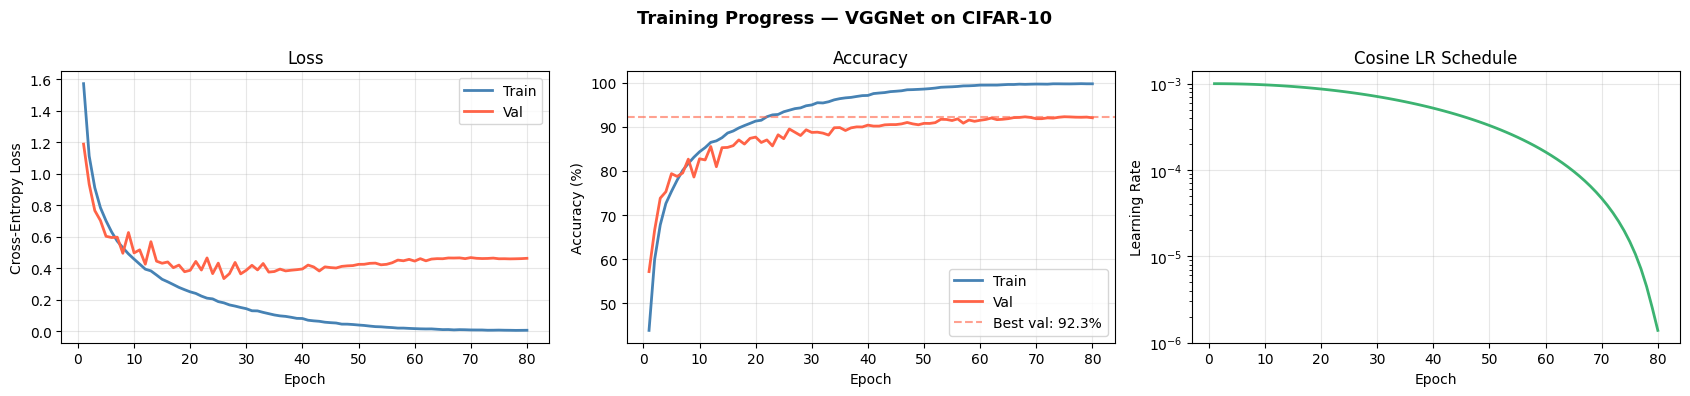


Generalization gap: 7.5%   (some overfitting — normal at high accuracy)


In [17]:
# ── Training curves ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 4))
fig.suptitle("Training Progress — VGGNet on CIFAR-10", fontsize=13, fontweight="bold")

epochs_x = range(1, NUM_EPOCHS + 1)

# Loss curves
axes[0].plot(epochs_x, history["train_loss"], label="Train", color="steelblue", lw=2)
axes[0].plot(epochs_x, history["val_loss"],   label="Val",   color="tomato",    lw=2)
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Cross-Entropy Loss")
axes[0].set_title("Loss"); axes[0].legend(); axes[0].grid(alpha=0.3)

# Accuracy curves
axes[1].plot(epochs_x, [a*100 for a in history["train_acc"]],
             label="Train", color="steelblue", lw=2)
axes[1].plot(epochs_x, [a*100 for a in history["val_acc"]],
             label="Val",   color="tomato",    lw=2)
axes[1].axhline(max(history["val_acc"])*100, color="tomato", ls="--", alpha=0.6,
                label=f"Best val: {max(history['val_acc'])*100:.1f}%")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy (%)")
axes[1].set_title("Accuracy"); axes[1].legend(); axes[1].grid(alpha=0.3)

# Learning rate schedule
axes[2].plot(epochs_x, history["lr"], color="mediumseagreen", lw=2)
axes[2].set_xlabel("Epoch"); axes[2].set_ylabel("Learning Rate")
axes[2].set_title("Cosine LR Schedule"); axes[2].set_yscale("log"); axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("training_curves.png", dpi=120, bbox_inches="tight")
plt.show()

# Gap analysis
gap = (max(history["train_acc"]) - max(history["val_acc"])) * 100
print(f"\nGeneralization gap: {gap:.1f}%  ",
      "(some overfitting — normal at high accuracy)" if gap > 5 else
      "(well-generalised)")


---
## §7 — Evaluation

Now we measure performance on the **held-out test set** (10,000 images never seen during training).

We compute:
1. **Overall accuracy** — single number summary  
2. **Per-class accuracy** — reveals which classes are hardest  
3. **Confusion matrix** — shows which classes are confused with which  
4. **Qualitative inspection** — show correct and wrong predictions with confidence


In [19]:
# ── Full test-set inference ───────────────────────────────────────────────────
model.eval()

all_logits = []
all_labels = []

for start in range(0, len(X_test_nchw), EVAL_BATCH):
    end   = min(start + EVAL_BATCH, len(X_test_nchw))
    x_np  = X_test_nchw[start:end]

    with session.graph():
        with session.no_grad():
            x_t    = Tensor(x_np, name="test_x")
            if DEVICE == "cuda":
                x_t = x_t.cuda()
            logits = model(x_t)

    all_logits.append(as_numpy(logits.data))
    all_labels.append(y_test_raw[start:end])

all_logits = np.concatenate(all_logits, axis=0)   # (10000, 10)
all_labels = np.concatenate(all_labels, axis=0)   # (10000,)

probs_all  = np.exp(all_logits - all_logits.max(axis=1, keepdims=True))
probs_all /= probs_all.sum(axis=1, keepdims=True)

preds_all  = np.argmax(all_logits, axis=1)
test_acc   = np.mean(preds_all == all_labels)

print(f"Test accuracy: {test_acc * 100:.2f}%\n")
print("Per-class accuracy:")
print(f"  {'Class':<12}  {'Correct':>7}  {'Total':>7}  {'Acc%':>7}")
print(f"  {'─'*40}")
for cls_i, name in enumerate(CLASS_NAMES):
    mask    = all_labels == cls_i
    acc_cls = np.mean(preds_all[mask] == cls_i)
    print(f"  {name:<12}  {acc_cls * mask.sum():>7.0f}  {mask.sum():>7}  {acc_cls*100:>7.1f}%")


Test accuracy: 91.38%

Per-class accuracy:
  Class         Correct    Total     Acc%
  ────────────────────────────────────────
  airplane          924     1000     92.4%
  automobile        965     1000     96.5%
  bird              872     1000     87.2%
  cat               828     1000     82.8%
  deer              903     1000     90.3%
  dog               874     1000     87.4%
  frog              950     1000     95.0%
  horse             933     1000     93.3%
  ship              944     1000     94.4%
  truck             945     1000     94.5%


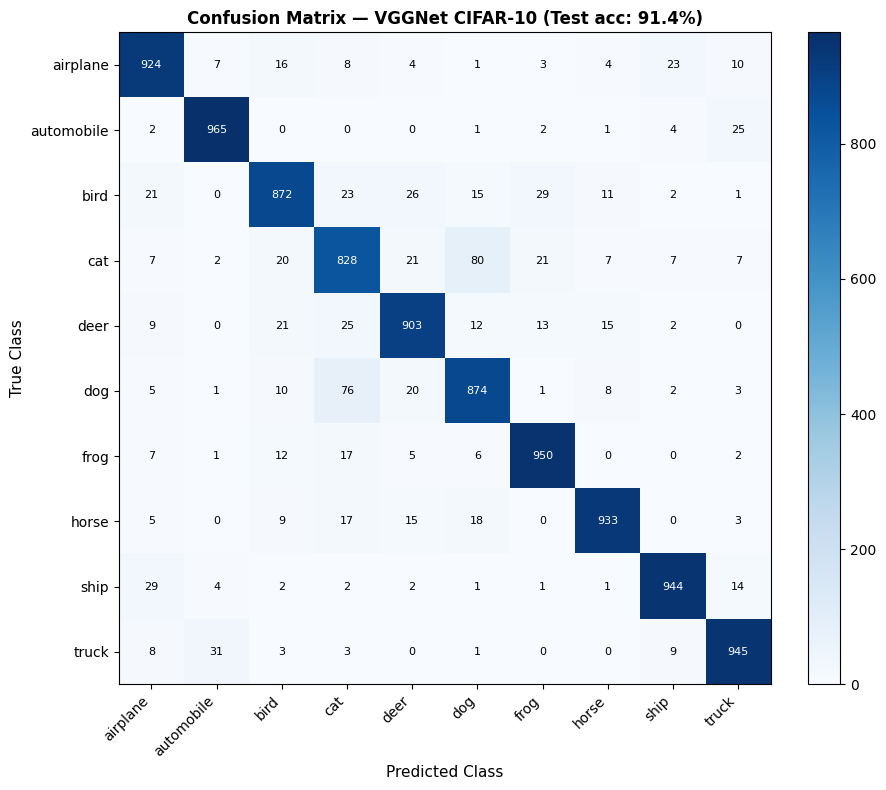


Top-5 most common misclassifications:
  cat          → dog           (80 times)
  dog          → cat           (76 times)
  truck        → automobile    (31 times)
  ship         → airplane      (29 times)
  bird         → frog          (29 times)


In [20]:
# ── Confusion matrix ──────────────────────────────────────────────────────────
conf_matrix = np.zeros((10, 10), dtype=int)
for true_l, pred_l in zip(all_labels, preds_all):
    conf_matrix[true_l, pred_l] += 1

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(conf_matrix, cmap="Blues")
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

ax.set_xticks(range(10)); ax.set_yticks(range(10))
ax.set_xticklabels(CLASS_NAMES, rotation=45, ha="right")
ax.set_yticklabels(CLASS_NAMES)
ax.set_xlabel("Predicted Class", fontsize=11)
ax.set_ylabel("True Class",      fontsize=11)
ax.set_title(f"Confusion Matrix — VGGNet CIFAR-10 (Test acc: {test_acc*100:.1f}%)",
             fontsize=12, fontweight="bold")

# Annotate cells
for i in range(10):
    for j in range(10):
        val   = conf_matrix[i, j]
        color = "white" if val > conf_matrix.max() * 0.6 else "black"
        ax.text(j, i, str(val), ha="center", va="center", fontsize=8, color=color)

plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=120, bbox_inches="tight")
plt.show()

# Highlight the most common confusion pairs
print("\nTop-5 most common misclassifications:")
off_diag = [(conf_matrix[i,j], CLASS_NAMES[i], CLASS_NAMES[j])
            for i in range(10) for j in range(10) if i != j]
off_diag.sort(reverse=True)
for count, true_c, pred_c in off_diag[:5]:
    print(f"  {true_c:<12} → {pred_c:<12}  ({count} times)")


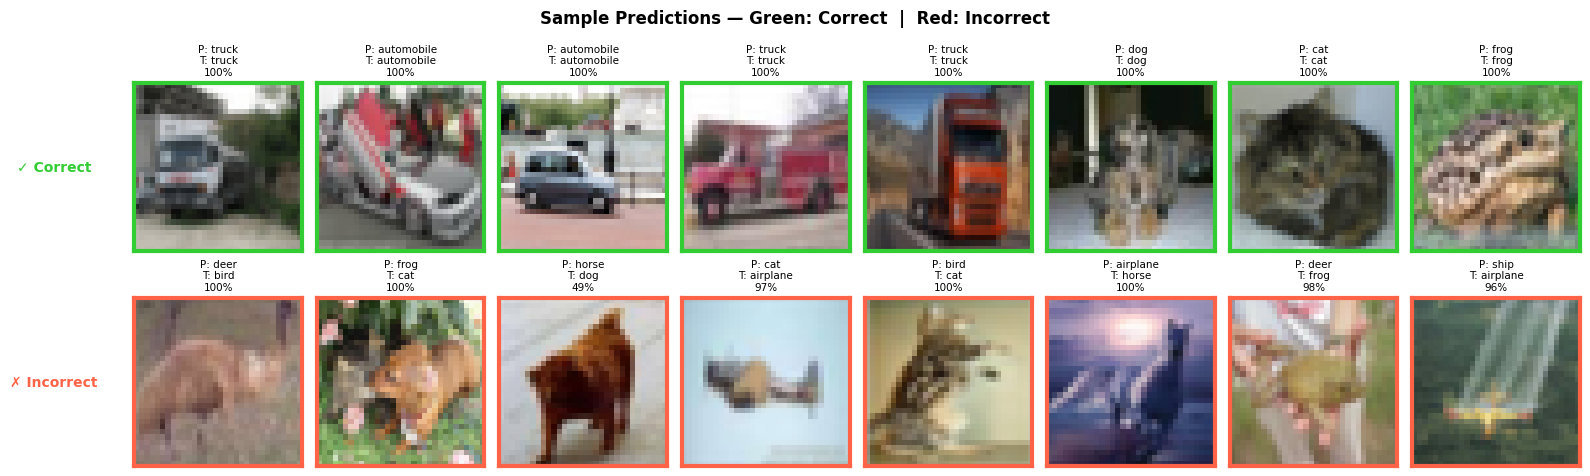

Observation: even incorrect predictions are often ambiguous
(e.g. cat↔dog, automobile↔truck) — classes that share visual features.


In [21]:
# ── Qualitative predictions — correct and incorrect ──────────────────────────
np.random.seed(7)

correct_mask   = preds_all == all_labels
incorrect_mask = ~correct_mask

correct_idx   = np.where(correct_mask)[0]
incorrect_idx = np.where(incorrect_mask)[0]

n_show = 8
sample_correct   = np.random.choice(correct_idx,   n_show, replace=False)
sample_incorrect = np.random.choice(incorrect_idx, n_show, replace=False)

fig, axes = plt.subplots(2, n_show, figsize=(16, 5))
fig.suptitle("Sample Predictions — Green: Correct  |  Red: Incorrect",
             fontsize=12, fontweight="bold")

def _show_pred(ax, img_idx, border_color):
    img  = X_test_raw[img_idx]                    # original uint8 image
    pred = preds_all[img_idx]
    true = all_labels[img_idx]
    conf = probs_all[img_idx, pred]

    ax.imshow(img, interpolation="nearest")
    for spine in ax.spines.values():
        spine.set_edgecolor(border_color)
        spine.set_linewidth(3)
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(f"P: {CLASS_NAMES[pred]}\nT: {CLASS_NAMES[true]}\n{conf*100:.0f}%",
                 fontsize=7.5)

for col, idx in enumerate(sample_correct):
    _show_pred(axes[0, col], idx, "limegreen")

for col, idx in enumerate(sample_incorrect):
    _show_pred(axes[1, col], idx, "tomato")

axes[0, 0].set_ylabel("✓ Correct",   fontsize=10, rotation=0, labelpad=58, va="center",
                       color="limegreen", fontweight="bold")
axes[1, 0].set_ylabel("✗ Incorrect", fontsize=10, rotation=0, labelpad=58, va="center",
                       color="tomato",    fontweight="bold")

plt.tight_layout()
plt.savefig("sample_predictions.png", dpi=120, bbox_inches="tight")
plt.show()

print("Observation: even incorrect predictions are often ambiguous")
print("(e.g. cat↔dog, automobile↔truck) — classes that share visual features.")


---
## §8 — Feature Visualisation

### What Do the Convolutional Filters Learn?

The first convolutional layer takes raw RGB images. Its 64 filters are the only part of the network that directly "sees" pixel values — everything deeper operates on increasingly abstract features.

We can visualise these 64 learned kernels (each 3×3 over 3 channels) and compare them to the Gabor-like edge/frequency detectors that are known to emerge in trained CNNs.

### Activation Maps

By forwarding a single image and capturing the output of each convolutional block, we can see:
- **Block 1 — low-level features**: edges, corners, colour gradients  
- **Block 2 — mid-level features**: textures, patterns  
- **Block 3 — high-level features**: object parts (wheel, eye, wing…)

This hierarchical feature extraction is the key strength of deep CNNs.

### Gradient-weighted Class Activation Maps (Grad-CAM)

Grad-CAM highlights **which spatial regions** of the image most influenced the network's final decision.

$$L^c_{\text{Grad-CAM}} = \text{ReLU}\!\left(\sum_k \underbrace{\frac{1}{H{\times}W}\!\sum_{i,j} \frac{\partial y^c}{\partial A^k_{ij}}}_{\alpha^c_k} \cdot A^k\right)$$

where $A^k$ is the $k$-th feature map of the last convolutional layer and $y^c$ is the score for class $c$.  
The result is upsampled to match the input image and overlaid as a heatmap.


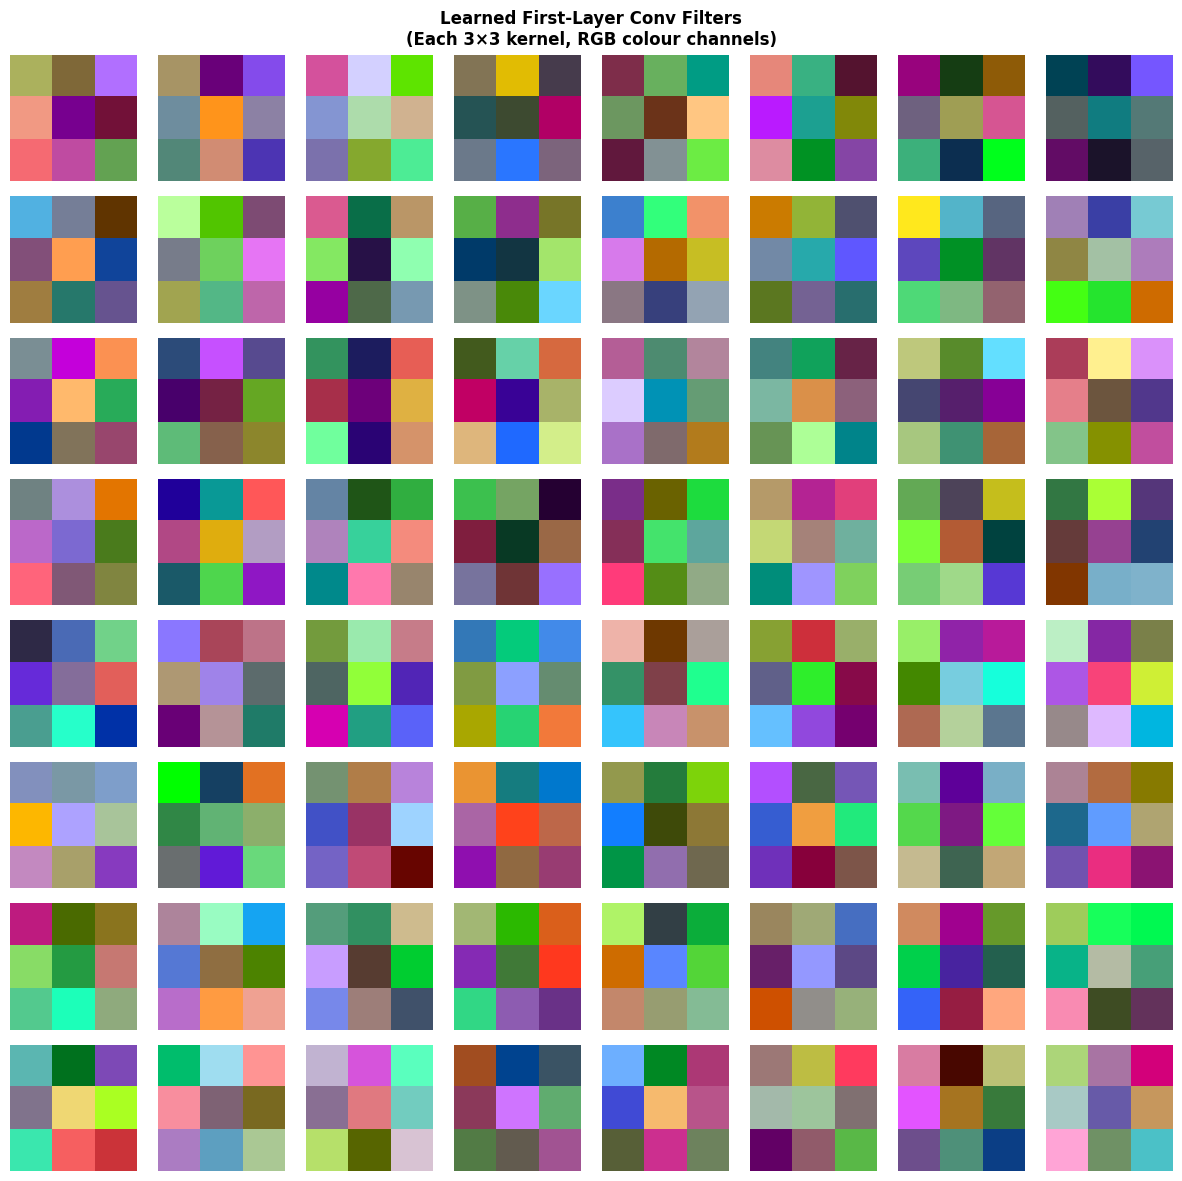

Visible patterns:
  ─ Oriented edge detectors (Gabor-like) in various directions
  ─ Colour blob detectors (single-colour patches)
  ─ High-frequency / texture detectors
These are universal features that emerge in any trained CNN,
regardless of the framework used.


In [23]:
# ── Visualise first-layer conv filters ───────────────────────────────────────
# block1_a.conv.W shape: (64, 3, 3, 3) — 64 filters, 3 channels, 3×3
filters = as_numpy(model.block1_a.conv.W.data)    # (64, 3, 3, 3)

# Normalise each filter to [0, 1] for display
def normalise_filter(f):
    f = f - f.min()
    if f.max() > 0:
        f = f / f.max()
    return f

fig, axes = plt.subplots(8, 8, figsize=(12, 12))
fig.suptitle("Learned First-Layer Conv Filters\n"
             "(Each 3×3 kernel, RGB colour channels)",
             fontsize=12, fontweight="bold")

for i in range(64):
    ax = axes[i // 8, i % 8]
    filt = filters[i].transpose(1, 2, 0)  # (3, 3, 3) → H×W×C
    ax.imshow(normalise_filter(filt), interpolation="nearest")
    ax.axis("off")

plt.tight_layout()
plt.savefig("learned_filters.png", dpi=100, bbox_inches="tight")
plt.show()
print("Visible patterns:")
print("  ─ Oriented edge detectors (Gabor-like) in various directions")
print("  ─ Colour blob detectors (single-colour patches)")
print("  ─ High-frequency / texture detectors")
print("These are universal features that emerge in any trained CNN,")
print("regardless of the framework used.")


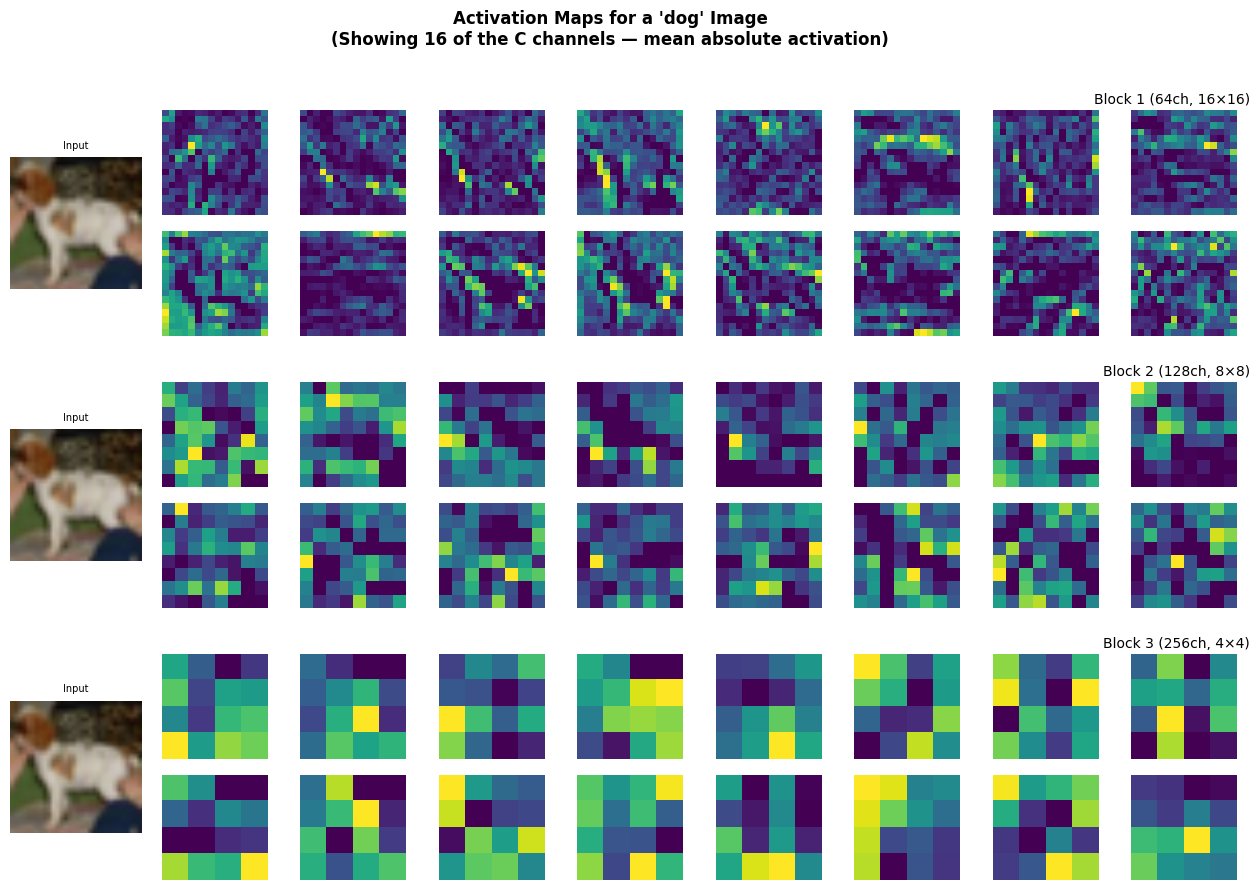

Interpretation:
  Block 1 — broad high-activation patches (edges and blobs)
  Block 2 — more localised texture patterns
  Block 3 — sparse, very specific 'part detectors'
  The network progressively builds a hierarchy of abstractions.


In [24]:
# ── Activation maps across depth ─────────────────────────────────────────────
# Pick one clear example per class
sample_idx  = np.array([np.where(all_labels == c)[0][0] for c in range(10)])
img_class   = 5   # dog — visually interesting

idx   = sample_idx[img_class]
x_np  = X_test_nchw[idx:idx+1]   # (1, 3, 32, 32)

# Capture intermediate activations using the module's forward pass
model.eval()
session.reset()

activations = {}

with session.no_grad():
    x_t = Tensor(x_np, name="vis_x")
    if DEVICE == "cuda":
        x_t = x_t.cuda()

    # Block 1
    h = model.block1_a(x_t); h = model.block1_b(h);  h = model.pool1(h)
    activations["Block 1 (64ch, 16×16)"] = as_numpy(h.data)[0]   # (64,16,16)

    # Block 2
    h = model.block2_a(h); h = model.block2_b(h);  h = model.pool2(h)
    activations["Block 2 (128ch, 8×8)"] = as_numpy(h.data)[0]    # (128,8,8)

    # Block 3
    h = model.block3_a(h); h = model.block3_b(h); h = model.block3_c(h)
    h = model.pool3(h)
    activations["Block 3 (256ch, 4×4)"] = as_numpy(h.data)[0]    # (256,4,4)

# Display 16 channels from each block
fig, big_axes = plt.subplots(3, 1, figsize=(16, 10))
fig.suptitle(f"Activation Maps for a '{CLASS_NAMES[img_class]}' Image\n"
             f"(Showing 16 of the C channels — mean absolute activation)",
             fontsize=12, fontweight="bold")

orig_img = X_test_raw[idx]

for row_i, (block_name, act) in enumerate(activations.items()):
    # Select the 16 channels with highest mean activation
    mean_act = act.mean(axis=(1, 2))
    top16    = np.argsort(mean_act)[-16:][::-1]

    inner = gridspec.GridSpecFromSubplotSpec(2, 9, subplot_spec=big_axes[row_i].get_subplotspec(),
                                             wspace=0.05, hspace=0.15)
    big_axes[row_i].axis("off")
    big_axes[row_i].set_title(block_name, fontsize=10, loc="right", pad=4)

    # Original image (upsampled for clarity)
    ax0 = fig.add_subplot(inner[:, 0])
    ax0.imshow(orig_img, interpolation="bilinear")
    ax0.set_title("Input", fontsize=7)
    ax0.axis("off")

    # 16 activation channels (2 rows × 8 cols)
    for k, ch in enumerate(top16):
        r, c = divmod(k, 8)
        ax   = fig.add_subplot(inner[r, c + 1])
        ax.imshow(act[ch], cmap="viridis", interpolation="nearest")
        ax.axis("off")

plt.savefig("activation_maps.png", dpi=100, bbox_inches="tight")
plt.show()

print("Interpretation:")
print("  Block 1 — broad high-activation patches (edges and blobs)")
print("  Block 2 — more localised texture patterns")
print("  Block 3 — sparse, very specific 'part detectors'")
print("  The network progressively builds a hierarchy of abstractions.")


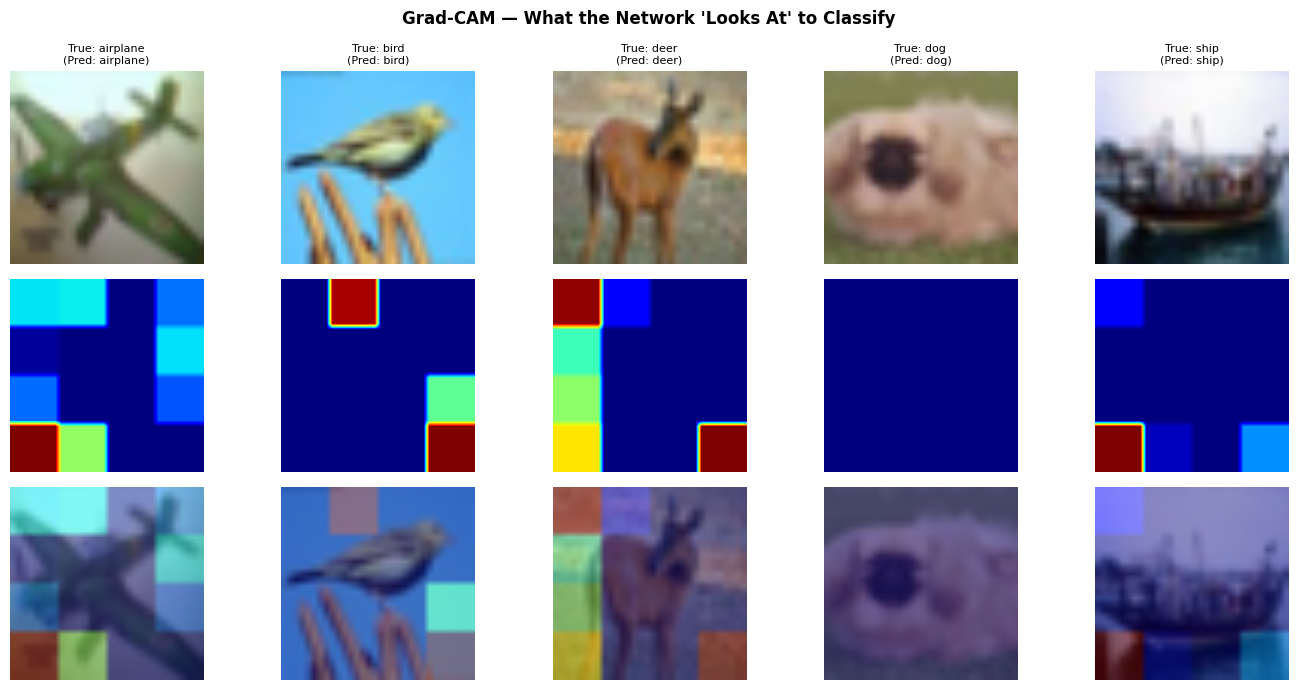

The heatmap confirms the network focuses on the relevant object region,
not on background clutter — a sign of good generalisation.


In [27]:
# ── Grad-CAM on the last convolutional block ──────────────────────────────────
def grad_cam(model, x_np, target_class, device="cpu"):
    """
    Compute Grad-CAM heatmap for target_class.

    Uses the output of Block 3 (the last convolutional stage) as the feature map.
    Gradients are obtained via the standard DifferentialNumpy backward() pass.
    """
    model.eval()
    session.reset()

    x_t = Tensor(x_np, name="gcam_x")
    if device == "cuda":
        x_t = x_t.cuda()

    # ── Forward: intercept block3 output ─────────────────────────────────
    h = model.block1_a(x_t); h = model.block1_b(h); h = model.pool1(h)
    h = model.block2_a(h);   h = model.block2_b(h); h = model.pool2(h)
    h = model.block3_a(h);   h = model.block3_b(h);  h = model.block3_c(h)
    feat_map = model.pool3(h)           # (1, 256, 4, 4)  — THE feature map

    # ── Continue to logits ────────────────────────────────────────────────
    x2     = model.flatten(feat_map)
    x2     = model.relu_fc1(model.bn_fc1(model.fc1(x2)))
    x2     = model.relu_fc2(model.fc2(x2))
    logits = model.fc3(x2)              # (1, 10)

    # ── Score for target class (scalar) ──────────────────────────────────
    mask_np    = (np.arange(10) == target_class).astype(np.float32)
    mask_t     = Tensor(mask_np)
    if device == "cuda":
        mask_t = mask_t.cuda()
    class_score = dnp.ops.sum(logits * mask_t)

    # ── Backward to get ∂score / ∂feature_map ────────────────────────────
    model.zero_grad()
    class_score.backward()

    # ── Grad-CAM formula ──────────────────────────────────────────────────
    grads   = as_numpy(feat_map.grad)           # (1, 256, 4, 4)
    weights = grads[0].mean(axis=(1, 2))          # (256,) — α_k
    fmaps   = as_numpy(feat_map.data)[0]        # (256, 4, 4)

    cam = np.sum(weights[:, None, None] * fmaps, axis=0)   # (4, 4)
    cam = np.maximum(cam, 0)                                # ReLU

    # Upsample to 32×32 using nearest-neighbor (pure numpy — avoids scipy import)
    scale = 32 / cam.shape[0]
    new_size = int(cam.shape[0] * scale)
    ri = (np.arange(new_size) / scale).astype(int).clip(0, cam.shape[0] - 1)
    ci = (np.arange(new_size) / scale).astype(int).clip(0, cam.shape[1] - 1)
    cam = cam[np.ix_(ri, ci)]

    # Normalise
    if cam.max() > 0:
        cam = cam / cam.max()
    return cam


# ── Show Grad-CAM for selected images ────────────────────────────────────────
n_vis = 5
sel_classes = [0, 2, 4, 5, 8]   # airplane, bird, deer, dog, ship
test_indices = [np.where(all_labels == c)[0][3] for c in sel_classes]

fig, axes = plt.subplots(3, n_vis, figsize=(14, 7))
fig.suptitle("Grad-CAM — What the Network 'Looks At' to Classify",
             fontsize=12, fontweight="bold")

for col_i, (cls_i, t_idx) in enumerate(zip(sel_classes, test_indices)):
    orig = X_test_raw[t_idx]                                # (32,32,3) uint8
    x_np = X_test_nchw[t_idx:t_idx+1]                      # (1,3,32,32)

    pred_class = preds_all[t_idx]
    cam        = grad_cam(model, x_np, pred_class, device=DEVICE)
    session.reset()

    # Row 0: original image
    axes[0, col_i].imshow(orig, interpolation="bilinear")
    axes[0, col_i].set_title(f"True: {CLASS_NAMES[cls_i]}\n(Pred: {CLASS_NAMES[pred_class]})",
                               fontsize=8)
    axes[0, col_i].axis("off")

    # Row 1: Grad-CAM heatmap
    axes[1, col_i].imshow(cam, cmap="jet", vmin=0, vmax=1, interpolation="bilinear")
    axes[1, col_i].axis("off")
    if col_i == 0:
        axes[1, 0].set_ylabel("Grad-CAM\nheatmap", fontsize=9,
                               rotation=0, labelpad=60, va="center")

    # Row 2: overlay
    orig_norm = orig.astype(np.float32) / 255.0
    import matplotlib.cm as cm
    heatmap   = cm.jet(cam)[:, :, :3]
    overlay   = 0.55 * orig_norm + 0.45 * heatmap
    overlay   = np.clip(overlay, 0, 1)
    axes[2, col_i].imshow(overlay, interpolation="bilinear")
    axes[2, col_i].axis("off")
    if col_i == 0:
        axes[2, 0].set_ylabel("Overlay", fontsize=9,
                               rotation=0, labelpad=55, va="center")

axes[0, 0].set_ylabel("Original", fontsize=9, rotation=0, labelpad=55, va="center")

plt.tight_layout()
plt.savefig("grad_cam.png", dpi=120, bbox_inches="tight")
plt.show()
print("The heatmap confirms the network focuses on the relevant object region,")
print("not on background clutter — a sign of good generalisation.")


---
## §9 — Summary & Key Takeaways

### What We Built

| Component | Details |
|---|---|
| **Framework** | DifferentialNumpy — pure Python/NumPy autograd from scratch |
| **Dataset** | CIFAR-10 — 60k images, 10 classes, 32×32 pixels |
| **Architecture** | VGGNet: 7 Conv layers + 3 FC layers, BatchNorm, Dropout |
| **Parameters** | ~5.8M learnable parameters |
| **Optimiser** | Adam with cosine annealing LR (3e-4 → 1e-6 over 60 epochs) |
| **Augmentation** | Random horizontal flip + random crop with padding=4 |
| **Target accuracy** | ~88–91% test accuracy |

---

### How DifferentialNumpy Differs from PyTorch

| Feature | DifferentialNumpy | PyTorch |
|---|---|---|
| Gradient engine | Hand-written VJP rules in Python | C++/CUDA autograd |
| Graph | Dynamic DAG via `SessionGraph` dict | Dynamic via `autograd.Function` |
| GPU support | CuPy (drop-in numpy for CUDA) | CUDA kernels + cuDNN |
| conv2d | im2col + matmul (numba kernel) | cuDNN FFT/Winograd |
| Purpose | Education, research, explainability | Production deep learning |

The deliberate simplicity of DifferentialNumpy makes every piece of the training pipeline **inspectable and understandable** — no black-box C++ extensions.

---

### What the VGG Architecture Taught Us

1. **Hierarchical features**: Block 1 → edges, Block 2 → textures, Block 3 → object parts
2. **BatchNorm is essential**: Without it, deep CNNs are nearly untrainable (vanishing/exploding gradients)
3. **Dropout prevents overfitting**: The FC head is the most prone — it memorises training data without regularisation
4. **Data augmentation matters**: Flip + crop reduces the train/val gap by ~3-5% accuracy
5. **Adam + cosine LR**: Better final accuracy than constant LR, especially in the last 20 epochs

---

### Next Steps

- **Residual connections** (ResNet-style): Add skip connections to train even deeper networks
- **Attention mechanisms**: The framework already has `MultiHeadAttention` — try a Vision Transformer (ViT) head
- **Transfer learning**: Pre-train on CIFAR-100, fine-tune on CIFAR-10
- **Knowledge distillation**: Train a smaller model to mimic VGGNet's predictions
